### Loading the Ames Housing Dataset into a DataFrame

In this section, we will load the Ames Housing dataset using the pandas read_csv function, which is fast and versatile and a recommend tool for working with tabular data stored in plaintext format.

The Ames Housing dataset consists of 2930 examples and 80 features. For simplicity, we will only work with a subset of the features. The features we will be working with are as follows:

• Overall Qual: Rating for the overall material and finish of the house on a scale from 1 (very poor) to 10 (excellent)

• Overall Cond: Rating for the overall condition of the house on a scale from 1 (very poor) to 10 (excellent)

• Gr Liv Area: Above grade (ground) living area in square feet

• Central Air: Central air conditioning (N=no, Y=yes)

• Total Bsmt SF: Total square feet of the basement area 

• SalePrice: Sale price in U.S. dollars ($)

SalePrice is our target variable, the variable that we want to predict using one or more of the five explanatory variables. Before we explore the dataset further, let's load it into a pandas DataFrame:

In [1]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
                 sep='\t',
                 usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


Let's make sure the DataFrame contains the expected number of rows (2930) as expected:

In [2]:
df.shape

(2930, 6)

Another aspect we have to take care of is the 'Central Air' variable, which is encoded as a string. We can use the map method to convert the strings to integers:

In [3]:
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})

Lastly, let's check if any of the columns contain missing values:

In [4]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

As we can see, Total Bsmt SF feature variable contains one missing value. Since we have a relatively large dataset, the easiest way to deal with the missing feature is to remove the corresponding example from the dataset:

In [5]:
df = df.dropna(axis=0)

### Visualizing the Important Characteristics of a Dataset

Exploratory data analysis (EDA) is an important and recommended first step prior to the training of a machine learning model. In the rest of this section, we will use some simple yet useful techniques from the graphical EDA toolbox that may help us to visually detect the presence of outliers, the distribution of the data, and the relationships between features.

First, we will create a scatterplot matrix that allows us to visualize the pair-wise correlations between the different features in the dataset in one place. To plot the scatterplot matrix, we will use the scatterplotmatrix function from the mlxtend library, which is a Python library that contains various convenience functions for machine learning and data science applications in Python.

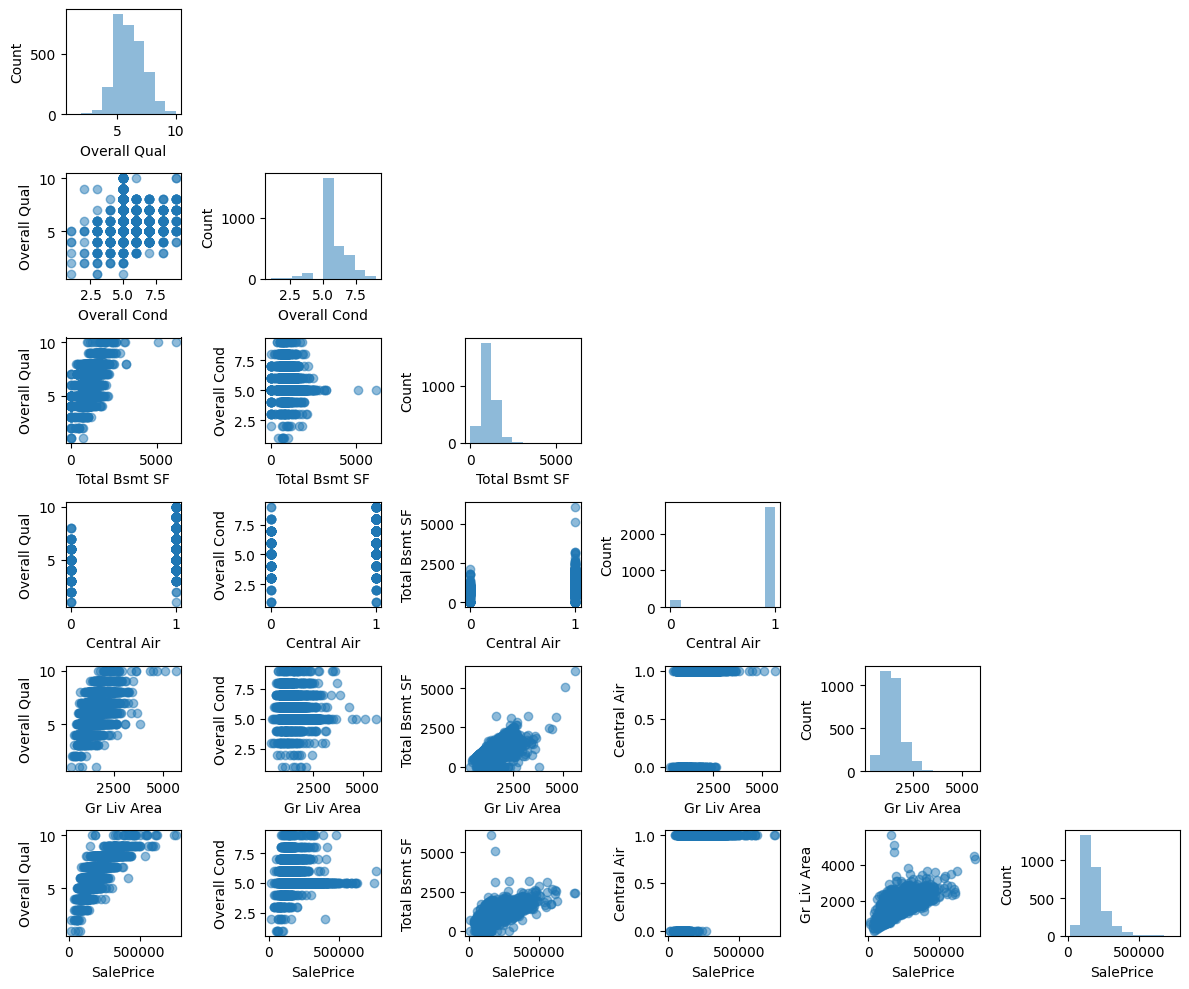

In [6]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10),
                  names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

Using this scatterplot matrix, we can now quickly see how the data is distributed and whether it contains outliers. For example, we can see that there is a somewhat linear relationship between the size of the living area above ground (Gr Liv Area) and the sale price (SalePrice). We can also see in the histogram at the lower right that the SalePrice variable seems to be skewed by several outliers.

### Looking at Relationships Using a Correlation Matrix

In the previous section, we visualized the data distributions of the Ames Housing dataset variables in the form of histograms and scatterplots. Next, we will create a correlation matrix to quantify and summarize linear relationships between variables. A correlation matrix is closely related to the covariance matrix. We can interpret the correlation matrix as being a rescaled version of the covariance matrix. In fact, the correlation matrix is identical to a covariance matrix computed from standardized features.

In the following code example, we will use corrcoef function on the five feature columns that we previously visualized in the scatterplot matrix, and we will use mlxtend's heatmap function to plot the correlation matrix array as a heat map:

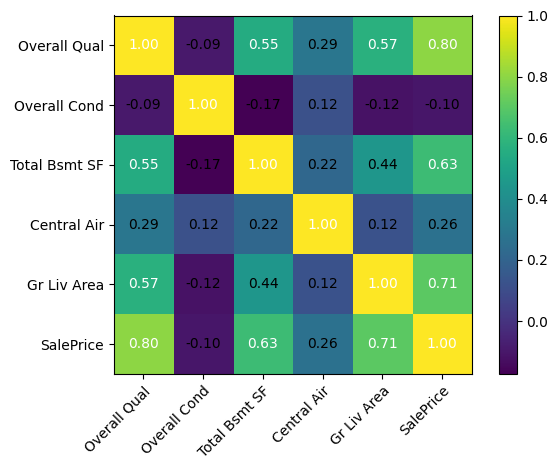

In [7]:
import numpy as np
from mlxtend.plotting import heatmap

cm  = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

To fit a linear regression model, we are interested in those features that have a high correlation with our target variable, SalePrice.

### Implementing an Ordinary Least Squares Linear Regression Model

Let's make a custom linear regression model using gradient descent, similar to Adaline but without the threshold function so that we obtain continuous target values instead of class labels:

In [8]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)
        
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    
    def predict(self, X):
        return self.net_input(X)

To see our LinearRegressionGD regressor in action, let's use the Gr Living Area (size of the living area above ground in square feet) feature from the Ames Housing dataset as the exploratory variable and train a model that can predict SalePrice. Furthermore, we will standardize the variables for better convergence of the GD algorithm:

In [9]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y.reshape(-1, 1)).ravel()
lr = LinearRegressionGD(eta=0.1)
lr = lr.fit(X_std, y_std)

We are using reshape to transform y_std into a two-dimensional array since most data preprocessing classes in scikit-learn expect data to be stored in two-dimensional arrays. Once we are done with scaling, we convert it back to the original one-dimensional array representation using ravel for convenience.

We can plot the loss as a function of the number of epochs over the training dataset when using optimization algorithms such as Gradient Descent:

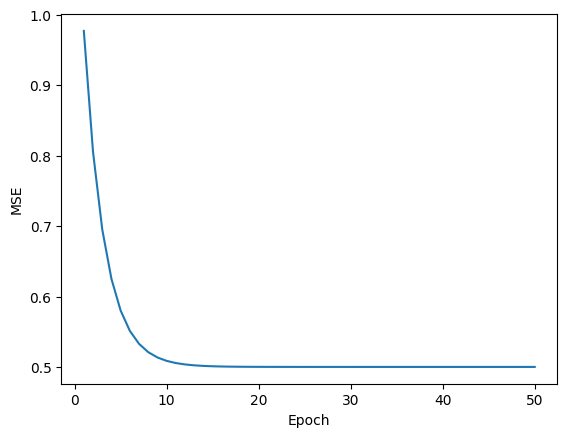

In [10]:
plt.plot(range(1, lr.n_iter + 1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.show()

We can see that the gradient descent algorithm converged approximately after the tenth epoch.

Next, let's visualize how well the linear regression line fits the training data. To do so, we will define a simple helper function that will plot a scatterplot of the training examples and add the regression line:

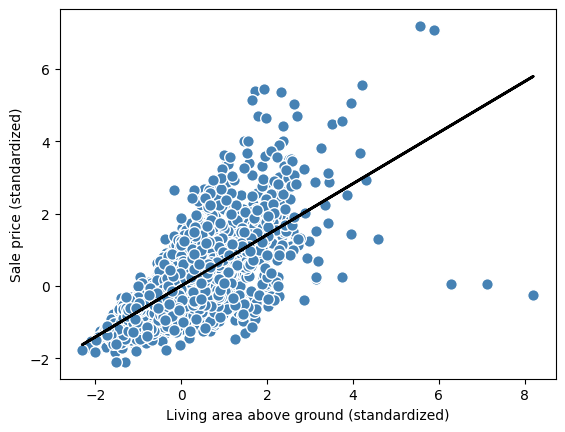

In [11]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)

lin_regplot(X_std, y_std, lr)
plt.xlabel('Living area above ground (standardized)')
plt.ylabel('Sale price (standardized)')
plt.show()

Although this observation makes sense, the data also tells us that the living area size does not explain house prices well in many cases. Interestingly, we can also observe several outliers, for example, the three data points corresponding to a standardized living area greater than 6. 

In certain applications, it may also be important to report the predicted outcome variables on their original scale. To scale the predicted price back onto the original price in US dollar scale, we can simply apply the inverse_transform method of the StandardScaler:

In [12]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sales price: ${target_reverted.ravel()[0]:.2f}')

Sales price: $292507.07


In this code example, we used the previously trained linear regression model to predict the price of a house aboveground living area of 2500 square feet. According to our model, such a house will be worth $292507.07.

### Estimating the Coefficient of a Regression Model via Scikit-Learn

In the previous section, we implemented a working model for regression analysis. However, in a real-world application, we may be interested in more efficient implementations. For example, many of scikit-learn's estimators for regression make use of the least squares implementation in SciPy, which in turn, uses highly optimized code optimizations based on the Linear Algebra Package (LAPACK). The linear regression implementation in scikit-learn also works better with unstandardized variables, since it does not use SGD based optimization, so we can skip the standardization step:

In [13]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'Slope: {slr.coef_[0]:.3f}')
print(f'Intercept: {slr.intercept_:.3f}')

Slope: 111.666
Intercept: 13342.979


As you can see from executing this code, scikit-learn's LinearRegression model, fitted with the unstandardized Gr Liv Area and SalePrice variables, yielded different model coefficients, since the features have not been standardized. However, when we compare it to our GD implementation by plotting SalePrice against Gr Liv Area, we can quantitatively see that it fits the data similarly well:

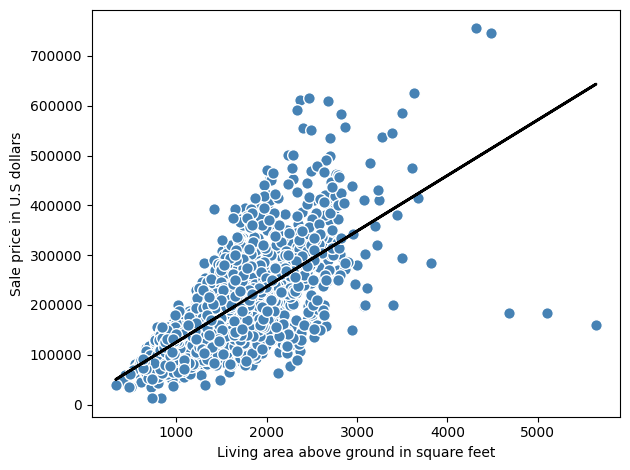

In [14]:
lin_regplot(X, y, slr)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S dollars')
plt.tight_layout()
plt.show()

We can also implement the closed form solution for solving OLS:

$$
w = (X^T X)^{-1}X^Ty
$$

In [15]:
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
w = np.zeros(X.shape[1])
z = np.linalg.inv(np.dot(Xb.T, Xb))
w = np.dot(z, np.dot(Xb.T, y))
print(f'Slope: {w[1]:.3f}')
print(f'Intercept: {w[0]:.3f}')

Slope: 111.666
Intercept: 13342.979


The advantage of this method is that it is guaranteed to find the optimal solution analytically. However, if we are working with large datasets, it can be computationally too expensive to invert the matrix in this formular or the matrix containing the training examples may be singular (non-invertible), which is why we may prefer iterative methods in certain cases.

### Fitting a Robust Regression Model using RANSAC

Let's now use a linear model with the RANSAC algorithm as implemented in scikit-learn RANSACRegressor class:

In [16]:
from sklearn.linear_model import RANSACRegressor

ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100,
    min_samples=0.95,
    residual_threshold=None,
    random_state=123
)
ransac = ransac.fit(X, y)

We set the maximum number of iterations of the RANSACRegressor to 100, and using min_samples=0.95, we set the minimum number of the randomly chosen training examples to be at least 95 percent of the dataset.

By default (via residual_threshold=None) scikit-learn uses the MAD estimate to select the inlier threshold, where MAD stands for the median absolute deviation of the target values, y. However, the choice of an appropriate value for the inlier threshold is problem-specific, which is one disadvantage of RANSAC. 

Many different approaches have been developed in recent years to select a good inlier threshold automatically. 

Once we have fitted the RANSAC model, let's obtain the inliers and outliers from the fitted RANSAC linear regression model and plot them together with the linear fit:

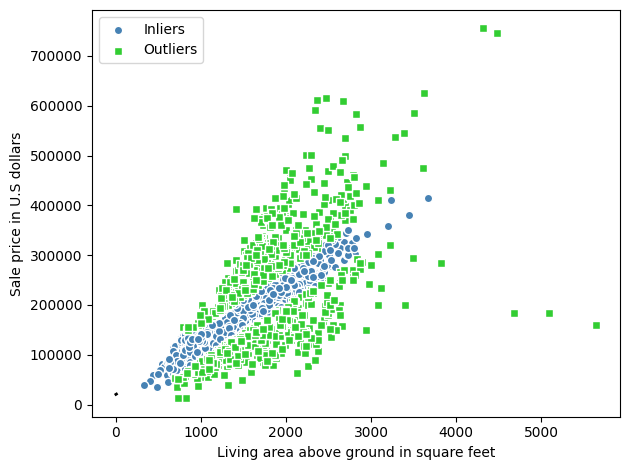

In [17]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X.reshape(-1, 1))
plt.scatter(X[inlier_mask], y[inlier_mask],
            c='steelblue', edgecolor='white',
            marker='o', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask],
            c='limegreen', edgecolor='white',
            marker='s', label='Outliers')
plt.plot(line_X, line_y_ransac, color='black', lw=2)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S dollars')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

When we print the slope and the intercept of the model by executing the following code, the linear regression line will be slightly different from the fit that we obtained in the previous section without using RANSAC:

In [18]:
print(f'Slope: {ransac.estimator_.coef_[0]:.3f}')
print(f'Intercept: {ransac.estimator_.intercept_:.3f}')

Slope: 106.348
Intercept: 20190.093


Remember that the RANSAC was using MAD to compute the threshold for flagging inliers and outliers. The MAD can be calculated for this dataset as follows:

In [19]:
def median_absolute_deviation(data):
    return np.median(np.abs(data - np.median(data)))

median_absolute_deviation(y)

np.float64(37000.0)

So if we want to identify fewer data points as outliers, we can choose a residual_threshold value greater than the preceding MAD.

Using RANSAC, we reduced the potential effect of outliers in this dataset, but we don't know whether this approach will have a positive effect on the predictive performance for unseen data or not. Thus, we will look at different approaches for evaluating a regression model, which is a crucial part of building systems for predictive modeling.

### Evaluating the Performance of Linear Regression Models

It is crucial to test the model on data it hasn't seen during training to obtain a more unbiased estimate of its generalization performance.

We want to split our dataset into separate training and test datasets, where we will use the former to fit the model and the latter to evaluate its performance on unseen data to estimate the generalization performance. Instead of proceeding with the simple regression model, we will now use all five features in the dataset and train a multiple regression model:

In [20]:
from sklearn.model_selection import train_test_split
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=123)
slr = LinearRegression()
slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

Since our model uses multiple explanatory variables, we can't visualize the linear regression line (or hyperplane) in a two-dimensional plot, but we can plot the residuals (the differences or vertical distances between the actual and predicted values) versus the predicted values to diagnose our regression model. 

Using the following code, we will now plot a residual plot where we simply subtract the true target variables from our predicted responses:

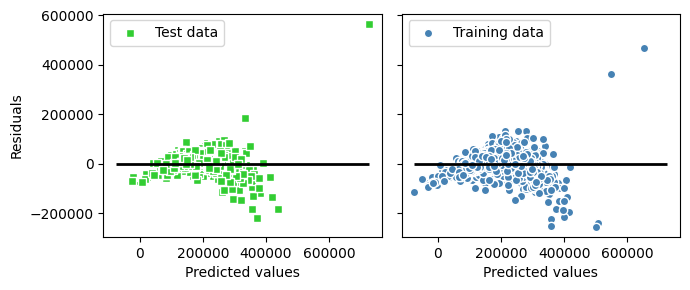

In [21]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(
    y_test_pred, y_test_pred - y_test, 
    c='limegreen', marker='s',
    edgecolor='white',
    label='Test data'
)

ax2.scatter(
    y_train_pred, y_train_pred - y_train, 
    c='steelblue', marker='o',
    edgecolor='white',
    label='Training data'
)

ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
              color='black', lw=2)

plt.tight_layout()
plt.show()

Let's now compute the MSE of our training and test predictions:

In [22]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

MSE train: 1497216245.85
MSE test: 1516565821.00


We can see that the MSE on the training dataset is less than that on the test set, which is an indicator that our model is slightly overfitting the training data in this case. 

We can compute MAE similar to MSE:

In [23]:
from sklearn.metrics import mean_absolute_error
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE train: {mae_train:.2f}')
print(f'MAE test: {mae_test:.2f}')

MAE train: 25983.03
MAE test: 24921.29


Based on the test set MAE, we can say that the model makes an error of approximately $25,000 on average.

Evaluated on the training data, the $R^2$ of our model is 0.77, which isn't great but also not too bad given that we only work with a small set of features. However, the $R^2$ on the test dataset is only slightly smaller, at 0.75, which indicates that the model is overfitting slightly:

In [24]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f'R^2 train: {train_r2:.3f}')
print(f'R^2 test: {test_r2:.3f}')

R^2 train: 0.769
R^2 test: 0.752


### Using Regularized Methods for Regression

A ridge regression model can be initialized via:

In [25]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)

Note that the regularization strength is regulated by the parameter alpha, which is similar to the parameter $\lambda$. Likewise, we can initialize a LASSO regressor from the linear_model submodule:

In [26]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)

Lastly, the ElasticNet implementation allows us to vary the L1 to L2 ratio:

In [27]:
from sklearn.linear_model import ElasticNet
elanet = ElasticNet(alpha=1.0, l1_ratio=0.5)

For example, if we set l1_ratio to 1.0, the ElasticNet regressor would be equal to LASSO regression.

### Turning a Linear Regression Model into a Curve - Polynomial Regression

We will now use the PolynomialFeatures transformer class from scikit-learn to add a quadratic term (d=2) to a simple regression problem with one explanatory variable. Then, we will compare the polynomial to the linear fit by following these steps:

In [28]:
from sklearn.preprocessing import PolynomialFeatures
X = np.array([258.0, 270.0, 294.0, 320.0, 342.0,
              368.0, 396.0, 446.0, 480.0, 586.0]).reshape(-1, 1)

y = np.array([236.4, 234.4, 252.8, 298.6, 314.2,
              342.2, 360.8, 368.0, 391.2, 390.8])

lr = LinearRegression()
pr = LinearRegression()
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)

Fit a simple linear regression model for comparison:

In [29]:
lr.fit(X,  y)
X_fit = np.arange(250, 600, 10).reshape(-1, 1)
y_lin_fit = lr.predict(X_fit)

Fit a multiple regression model on the transformed features for polynomial regression:

In [30]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(quadratic.fit_transform(X_fit))

Plot the results:

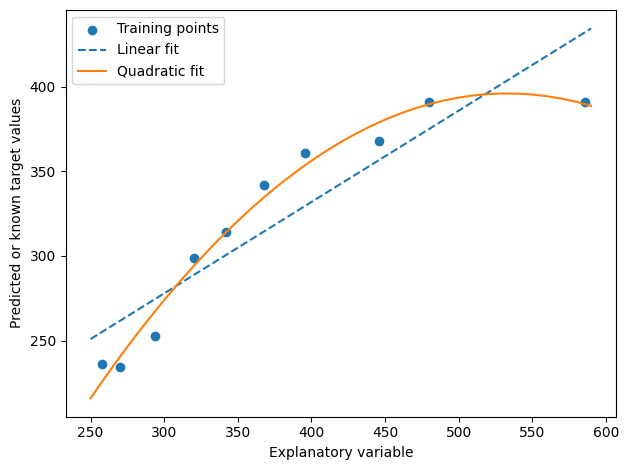

In [31]:
plt.scatter(X, y,label='Training points')
plt.plot(X_fit, y_lin_fit, 
         label='Linear fit', linestyle='--')
plt.plot(X_fit, y_quad_fit, 
         label='Quadratic fit')
plt.xlabel('Explanatory variable')
plt.ylabel('Predicted or known target values')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Next, we will compute the MSE and $R^2$ evaluation metrics:

In [32]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)
mse_lin = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)
print(f'Training MSE linear: {mse_lin:.3f}')
print(f'Training MSE quadratic: {mse_quad:.3f}')
r2_lin = r2_score(y, y_lin_pred)
r2_quad = r2_score(y, y_quad_pred)
print(f'Training R^2 linear: {r2_lin:.3f}')
print(f'Training R^2 quadratic: {r2_quad:.3f}')

Training MSE linear: 569.780
Training MSE quadratic: 61.330
Training R^2 linear: 0.832
Training R^2 quadratic: 0.982


As we can see, the MSE decreased from 570 to 61, and the coefficient of determination reflects a closer fit of the quadratic model as opposed to the linear fit in this particular problem.

### Modeling Nonlinear Relationships in the Ames Housing Dataset

Now, let's take a look at a more concrete example and apply polynomial features to fit nonlinear relationships again. By executing the following code, we will model the relationship between sale prices and the living area above ground using second-degree and third-degree polynomials and compare that to a linear fit.

We start by removing the three outliers with a living area greater than 4000 square feet, which we can see in previous figures, so that these outliers don't skew our regression fits:

In [33]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
X = X[(df['Gr Liv Area'] < 4000)]
y = y[(df['Gr Liv Area'] < 4000)]

Next, we fit the regression models:

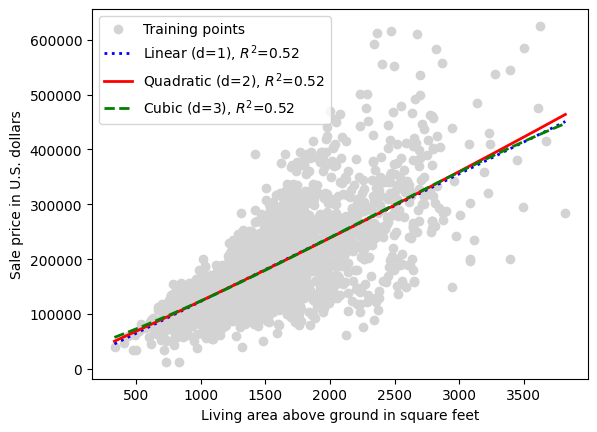

In [34]:
regr = LinearRegression()

#create quadratic and cubic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

# fit to features
X_fit = np.arange(X.min() - 1, X.max() + 2, 1).reshape(-1, 1)
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))

# plot results
plt.scatter(X, y, label='Training points', color='lightgray')
plt.plot(X_fit, y_lin_fit, label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue',
         lw=2,
         linestyle=':')
plt.plot(X_fit, y_quad_fit, label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red',
         lw=2,
         linestyle='-')
plt.plot(X_fit, y_cubic_fit, label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green',
         lw=2,
         linestyle='--')
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.show()

As we can see, the quadratic or cubic features does not really have an effect. That's because the relationships between the two variables appears to be linear. So, let's take a look at another feature, namely, Overall Qual. The Overall Qual variable rates the overall quality of the material and finish of the houses and is given on a scale from 1 to 10, where 10 is the best:

In [35]:
X = df[['Overall Qual']].values
y = df['SalePrice'].values

We can reuse the previous code to obtain the plot:

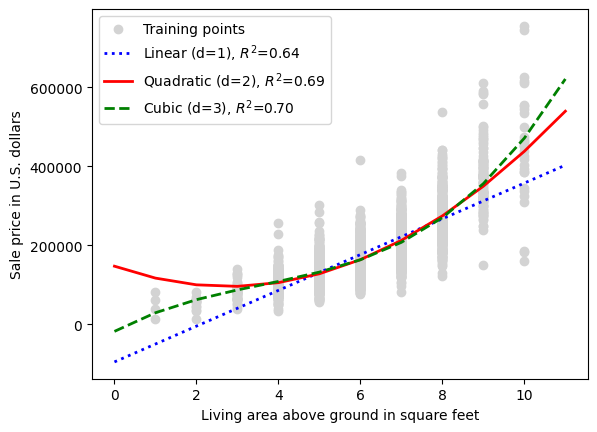

In [36]:
regr = LinearRegression()

#create quadratic and cubic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

# fit to features
X_fit = np.arange(X.min() - 1, X.max() + 2, 1).reshape(-1, 1)
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))

# plot results
plt.scatter(X, y, label='Training points', color='lightgray')
plt.plot(X_fit, y_lin_fit, label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue',
         lw=2,
         linestyle=':')
plt.plot(X_fit, y_quad_fit, label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red',
         lw=2,
         linestyle='-')
plt.plot(X_fit, y_cubic_fit, label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green',
         lw=2,
         linestyle='--')
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.show()

As we can see, the quadratic and cubic fits capture the relationships between sale prices and the overall quality of the house better than the linear fit. However, you should be aware that adding more and more polynomial features increases the complexity of a model and therefore increases the chance of overfitting. Thus, in practice, it is recommended to evaluate the performance of the model on a separate test dataset to estimate the generalization performance.

### Dealing with Nonlinear Relationships using Random Forests

To see what the line fit of a decision tree looks like, let's use the DecisionTreeRegressor implemented in scikit-learn to model the relationship between the SalePrice and Gr Living Area variables. Note that the SalePrice and Gr Living Area do not necessarily represent a nonlinear relationship, but this feature combination still demonstrates the general aspects of a regression tree quite nicely:

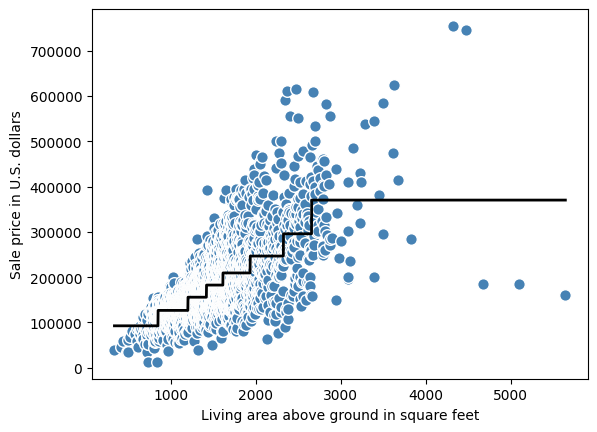

In [37]:
from sklearn.tree import DecisionTreeRegressor
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)

sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.show()


As we can see in the resulting plot, the decision tree captures the general trend in the data. And we can imagine that a regression tree could also capture trends in nonlinear data relatively well. However, a limitation of this model is that it does not capture the continuity and differentiability of the desired prediction. In addition, we need to be careful about choosing an appropriate value for the depth of the tree so as to not overfit or underfit the data.

### Random Forest Regression

Now, let's use all the features in the Ames Housing dataset to fit a random forest regression model on 70 percent of the examples and evaluate its performance on the remaining 30 percent:

In [38]:
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=123)

from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(n_estimators=1000,
                               criterion='squared_error',
                               random_state=1,
                               n_jobs=-1)
forest.fit(X_train, y_train)
y_train_pred= forest.predict(X_train)
y_test_pred = forest.predict(X_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f'MAE train: {mae_train:.2f}')
print(f'MAE test: {mae_test:.2f}')

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

MAE train: 8305.18
MAE test: 20821.77
R^2 train: 0.98
R^2 test: 0.85


Unfortunately, we can see that the random forest tends to overfit the training data. However, it's still able to explain the relationship between the target and explanatory variables relatively well ($R^2 = 0.85$ on the test dataset). For comparison, the linear model from the previous section, was overfitting less but performed worse on the test dataset ($R^2 = 0.75$).

Let's also take a look at the residuals of the prediction:

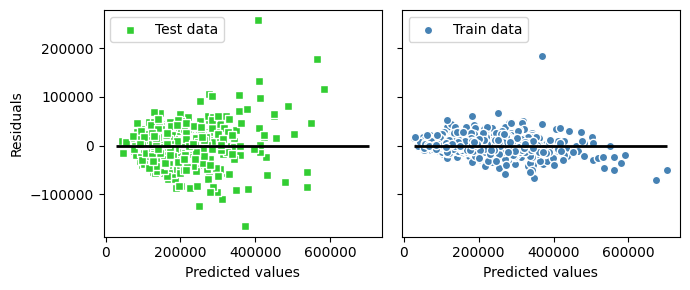

In [39]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test, 
            c='limegreen', marker='s',
            edgecolor='white',
            label='Test data')

ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o',
            edgecolor='white',
            label='Train data')

ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
              color='black', lw=2)

plt.tight_layout()
plt.show()

We can see that the model fits the training data better than the test data, as inficated by the outliers in the y axis direction. Also, the distribution of the residuals does not seem to be completely random around the zero center point, indicating that the model is not able to capture all the exploratory information. However, the residual plot indicates a large improvement over the residual plot of the linear model that we plotted earlier.

Ideally, our model error should be random or unpredictable. In other words, the error of the predictions should not be related to any of the infromation contained in the explanatory variables, rather it should reflect the randomness of the real-world distributions or patterns. If we find patterns in the prediction errors, for example, by inspecting the residual plot, it means that the residual plots contain predictive information. A common reason for this could be that explanatory informationis leaking into those residuals. 

Unfortunately, there is not a universal approach for dealing with non-randomness in residual plots, and it requires experimentation. Depending on the data that is available to us, we may be able to improve the model by transforming variables, tuning the hyperparameters of the learning algorithm, choosing simpler or more complex models, removing outliers, or including additional variables.